# SPX 5-Minute GARCH(1,1) Volatility Forecast

Goal: use the last 5-minute dynamics to forecast the **next 5-minute volatility**.

What this notebook does:
1. Build 5-minute returns and 5-minute realised volatility from the 1-minute SPX file.
2. Split chronologically into train/test (80/20).
3. Calibrate a GARCH(1,1) model on train data.
4. Produce 1-step-ahead out-of-sample volatility forecasts on the full test data.
5. Show concise performance stats and core diagnostic charts.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
import sys
sys.path.append("..")
import backend.Functions as fc

TRADING_DAYS = 252
BARS_PER_DAY = 78  # 390 minutes / 5
ANN_5M = np.sqrt(TRADING_DAYS * BARS_PER_DAY)
SCALE = 100.0

plt.rcParams.update({'figure.dpi': 130, 'axes.grid': True, 'grid.alpha': 0.3})

In [2]:
import sys
sys.path.append("..")
from project_paths import DATA_DIR

df5 = pd.read_parquet(DATA_DIR / "train_features_5m_clean.parquet")
df5 = df5[["bar5", "prev_5m_log_return_1", "target_ann_vol"]]

# Convert bar5 to date for filtering
df5_date = pd.to_datetime(df5["bar5"]).dt.date
train_data = df5[df5_date < pd.Timestamp("2025-10-03").date()]
test_data = df5[df5_date >= pd.Timestamp("2025-10-06").date()]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Train data sample:\n{train_data.tail()}")

Train data shape: (9628, 3)
Test data shape: (4303, 3)
Train data sample:
                    bar5  prev_5m_log_return_1  target_ann_vol
9623 2025-10-02 15:35:00             -0.000140        0.060708
9624 2025-10-02 15:40:00             -0.000500        0.045145
9625 2025-10-02 15:45:00             -0.000010        0.025070
9626 2025-10-02 15:50:00              0.000156        0.062959
9627 2025-10-02 15:55:00             -0.000287        0.050250


In [3]:
log_returns_test = test_data["prev_5m_log_return_1"].to_numpy(dtype=float)
log_returns_train = train_data["prev_5m_log_return_1"].to_numpy(dtype=float)

actual_train_vols = train_data["target_ann_vol"].to_numpy(dtype=float)
actual_test_vols = test_data["target_ann_vol"].to_numpy(dtype=float)

print(f'Train bins: {len(train_data):,} | Test bins: {len(test_data):,}')

Train bins: 9,628 | Test bins: 4,303


In [4]:
# Scale returns to % — GARCH optimizer is sensitive to very small values
r_full = pd.Series(np.concatenate([log_returns_train, log_returns_test])) * SCALE
n_train = len(log_returns_train)
n_test  = len(log_returns_test)

arch = arch_model(r_full, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=False)
res = arch.fit(last_obs=n_train, disp='off', update_freq=0)

# In-sample conditional vol (% units → divide back)
vol_train = (res.conditional_volatility.iloc[:n_train].to_numpy()/SCALE) * ANN_5M

# Out-of-sample 1-step-ahead forecasts: iloc[n_train:] gives exactly the test rows
fc_obj = res.forecast(horizon=1, start=n_train, reindex=True)
fc_var = fc_obj.variance['h.1'].iloc[n_train:n_train + n_test].to_numpy()
vol_test = (np.sqrt(fc_var) / SCALE) * ANN_5M

train_results = pd.DataFrame({
    "date": pd.to_datetime(train_data["bar5"], errors="coerce").to_numpy(),
    "actual_vol": actual_train_vols,
    "forecast_vol": vol_train,
    "error": actual_train_vols - vol_train,
})

test_results = pd.DataFrame({
    "date": pd.to_datetime(test_data["bar5"], errors="coerce").to_numpy(),
    "actual_vol": actual_test_vols,
    "forecast_vol": vol_test,
    "error": actual_test_vols - vol_test,
})
res.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                11117.9
Distribution:                  Normal   AIC:                          -22227.8
Method:            Maximum Likelihood   BIC:                          -22199.1
                                        No. Observations:                 9628
Date:                Thu, Jun 11 2026   Df Residuals:                     9627
Time:                        11:58:23   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         9.8155e-04  1.100e-03      0.893      0.372 [-1.174e-03,3.137e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      3.2151e-04  4.563e-04      0.705      0.481 [-5.728e-04,1.216e-03]
alpha[1]       0.2002      0.115      1.740  8.180e-02   [-2.526e-02,  0.426]
beta[1]        0.7798      0.148      5.281  1.282e-07      [  0.490,  1.069]
=============================================================================

Covariance estimator: robust
"""

In [5]:
# In-sample fit stats (train realized vs train fitted)
train_fit_stats = fc.regression_metrics(
    actual_train_vols,
    vol_train,
    prefix="train_fit"
 )

# Out-of-sample forecast stats (test realized vs test forecast)
test_forecast_stats = fc.regression_metrics(
    actual_test_vols,
    vol_test,
    prefix="test_fcst"
 )

all_stats = pd.concat([train_fit_stats, test_forecast_stats])
all_stats

train_fit_MAE     0.048293
train_fit_RMSE    0.103369
train_fit_Bias   -0.024326
train_fit_Corr    0.677479
train_fit_R2      0.458978
test_fcst_MAE     0.035699
test_fcst_RMSE    0.047063
test_fcst_Bias   -0.017398
test_fcst_Corr    0.695218
test_fcst_R2      0.483329
dtype: float64

Test days available: 61  |  fc_plot range: 0.054286 – 0.407712
Random test day: 2025-11-17
Bins on that day: 73


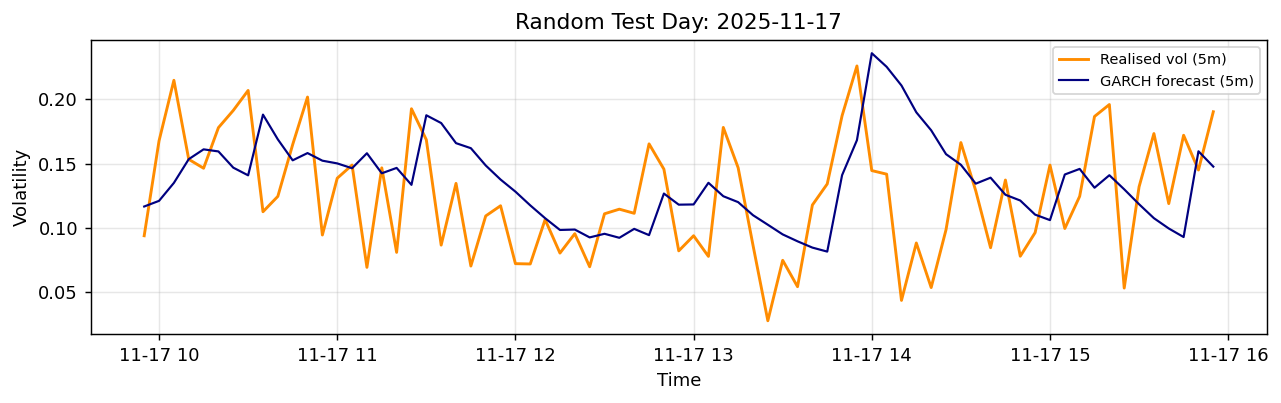

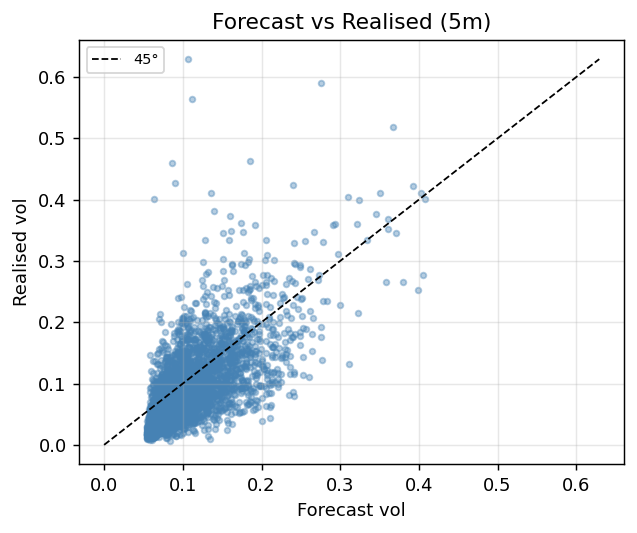

In [6]:
# 9) Visual checks
snap_dt  = pd.to_datetime(test_data["bar5"].values)
snap_date = np.array([t.date() for t in snap_dt])   # plain Python date objects — no tz issues

rv_plot = actual_test_vols  # numpy array
fc_plot = vol_test          # numpy array

unique_dates = np.unique(snap_date)
print(f"Test days available: {len(unique_dates)}  |  fc_plot range: {fc_plot.min():.6f} – {fc_plot.max():.6f}")

rng = np.random.default_rng(43)
chosen_date = rng.choice(unique_dates, size=1, replace=False)[0]
print(f"Random test day: {chosen_date}")

day_mask = snap_date == chosen_date
print(f"Bins on that day: {day_mask.sum()}")

# A) One chart for the random day
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(snap_dt[day_mask], rv_plot[day_mask], color='darkorange', lw=1.6, label='Realised vol (5m)')
ax.plot(snap_dt[day_mask], fc_plot[day_mask], color='navy',       lw=1.2, label='GARCH forecast (5m)')
ax.set_title(f'Random Test Day: {chosen_date}')
ax.set_xlabel('Time')
ax.set_ylabel('Volatility')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# B) Global diagnostic scatter
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.scatter(fc_plot, rv_plot, s=10, alpha=0.4, color='steelblue')
m = float(max(fc_plot.max(), rv_plot.max()))
ax.plot([0, m], [0, m], 'k--', lw=1, label='45°')
ax.set_title('Forecast vs Realised (5m)')
ax.set_xlabel('Forecast vol')
ax.set_ylabel('Realised vol')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


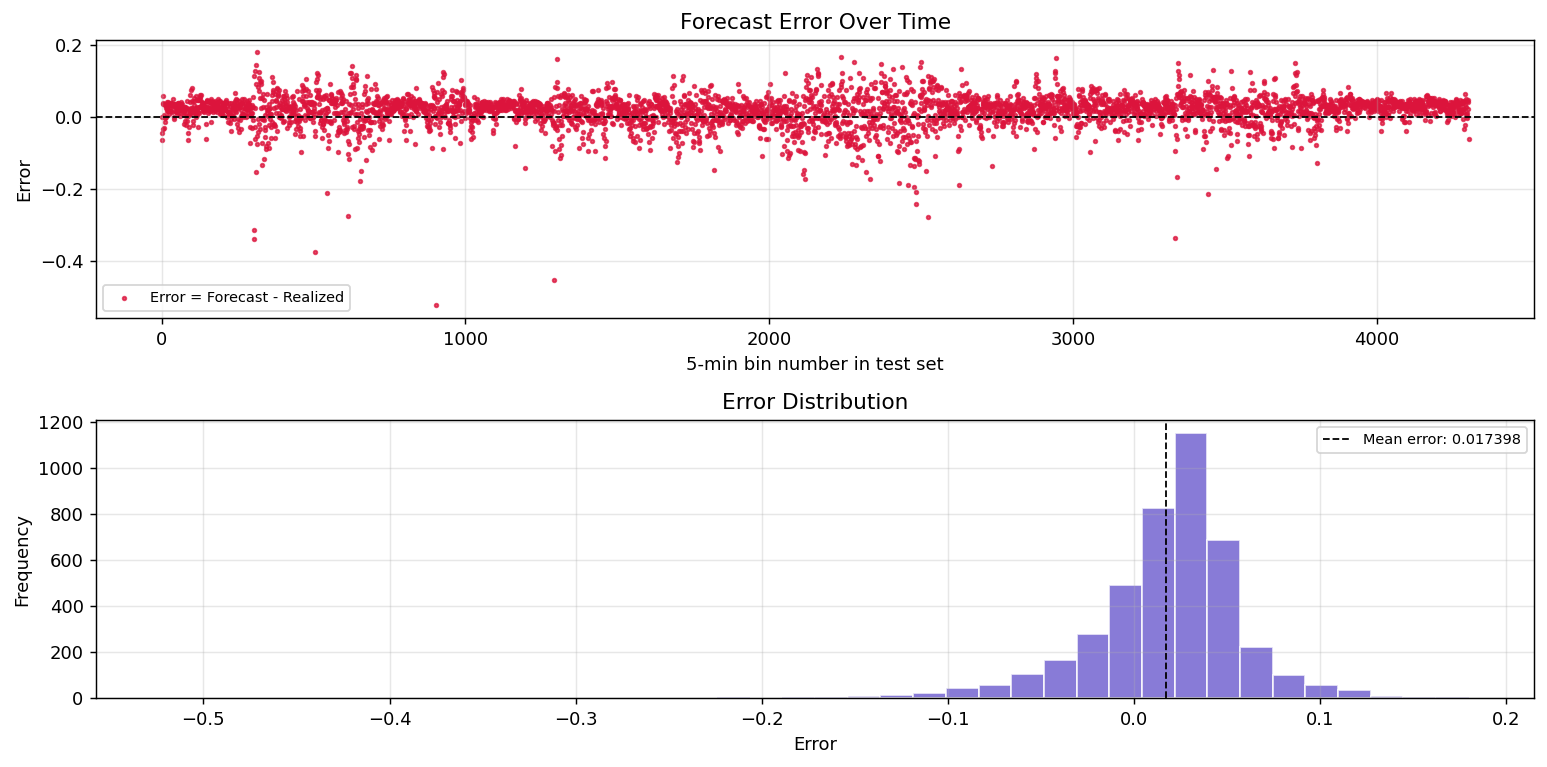

In [7]:
# 10) Error plots: residual over time + distribution (no session gaps)
errors = fc_plot - rv_plot  # forecast error (numpy array)
err_x = np.arange(len(errors))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

# A) Error over continuous 5-min bin index (scatter, no line plot)
axes[0].scatter(err_x, errors, color='crimson', s=4, alpha=0.75, label='Error = Forecast - Realized')
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_title('Forecast Error Over Time')
axes[0].set_xlabel('5-min bin number in test set')
axes[0].set_ylabel('Error')
axes[0].legend(fontsize=8)

# B) Error distribution
axes[1].hist(errors, bins=40, color='slateblue', alpha=0.8, edgecolor='white')
axes[1].axvline(errors.mean(), color='black', ls='--', lw=1, label=f"Mean error: {errors.mean():.6f}")
axes[1].set_title('Error Distribution')
axes[1].set_xlabel('Error')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


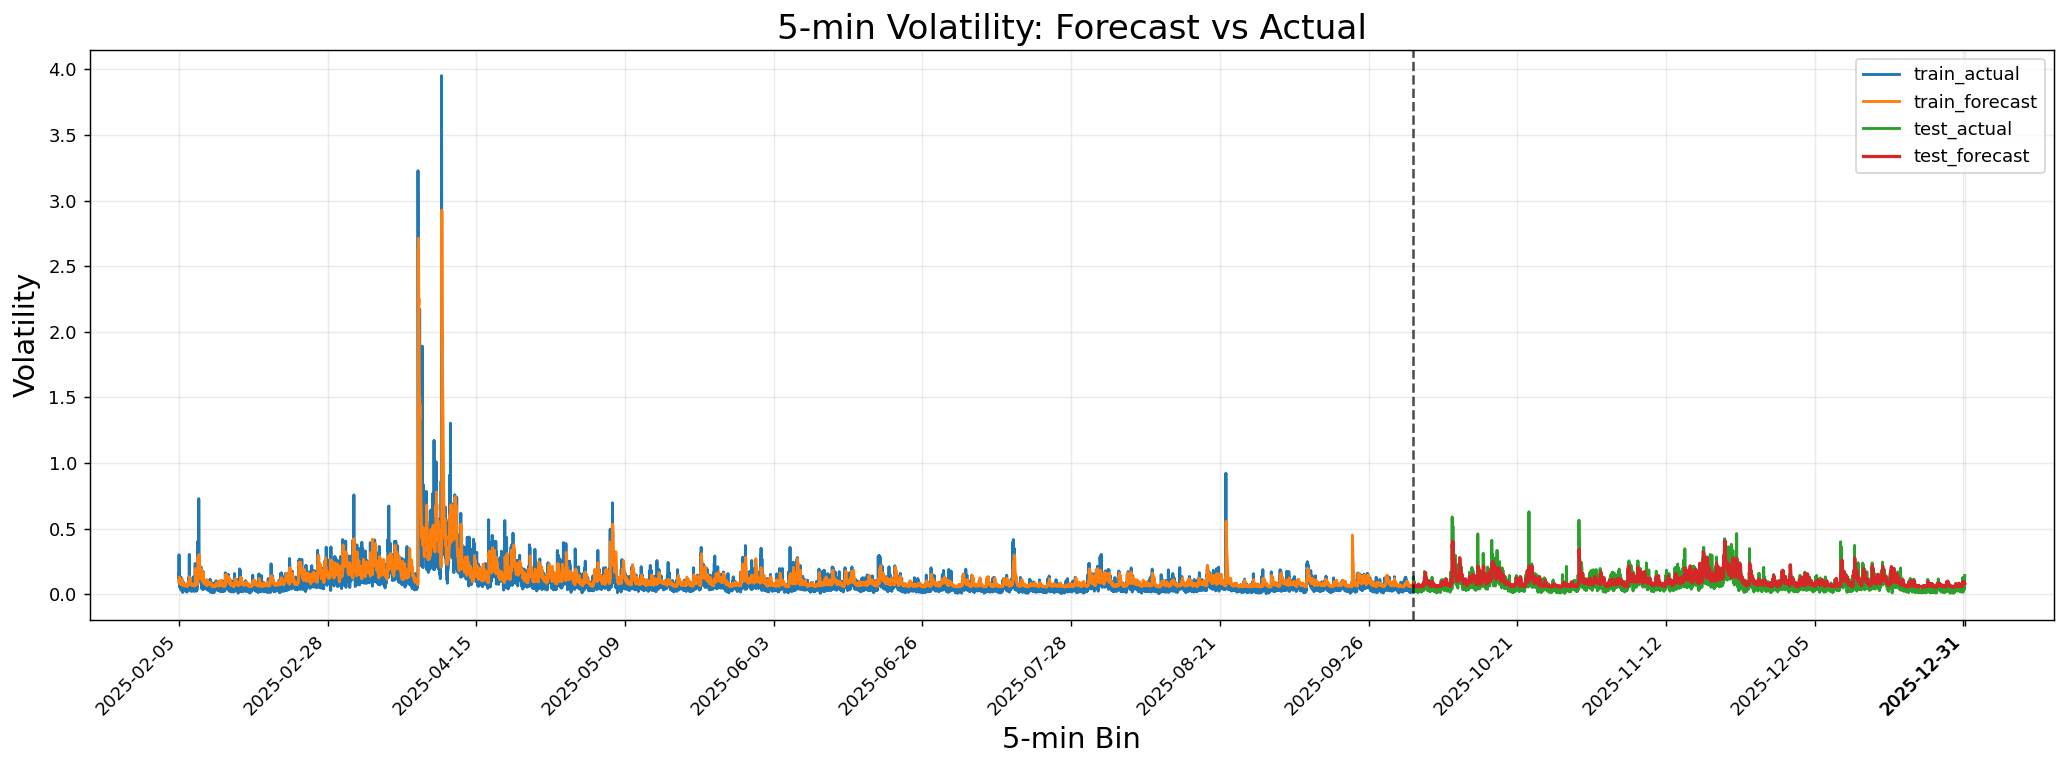

In [8]:
train_snap = pd.to_datetime(train_data["bar5"].values)
test_snap  = pd.to_datetime(test_data["bar5"].values)

train_x  = np.arange(len(vol_train))
test_x   = np.arange(len(vol_train), len(vol_train) + len(vol_test))
split_x  = len(vol_train) - 0.5

all_dates = list(train_snap.strftime("%Y-%m-%d")) + list(test_snap.strftime("%Y-%m-%d"))
all_x     = np.arange(len(all_dates))
tick_step = max(1, len(all_x) // 12)
tick_idx  = list(range(0, len(all_x), tick_step))
if tick_idx[-1] != len(all_x) - 1:
    tick_idx.append(len(all_x) - 1)

plt.figure(figsize=(16, 6))
plt.plot(train_x, actual_train_vols, label="train_actual",   linewidth=1.6)
plt.plot(train_x, vol_train,         label="train_forecast", linewidth=1.6)
plt.plot(test_x,  actual_test_vols,  label="test_actual",    linewidth=1.6)
plt.plot(test_x,  vol_test,          label="test_forecast",  linewidth=1.8)

plt.axvline(split_x, color="black", linestyle="--", linewidth=1.4, alpha=0.7)
plt.xticks(tick_idx, [all_dates[i] for i in tick_idx], rotation=45, ha="right")
plt.title("5-min Volatility: Forecast vs Actual", fontsize=19)
plt.xlabel("5-min Bin", fontsize=16)
plt.ylabel("Volatility", fontsize=16)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


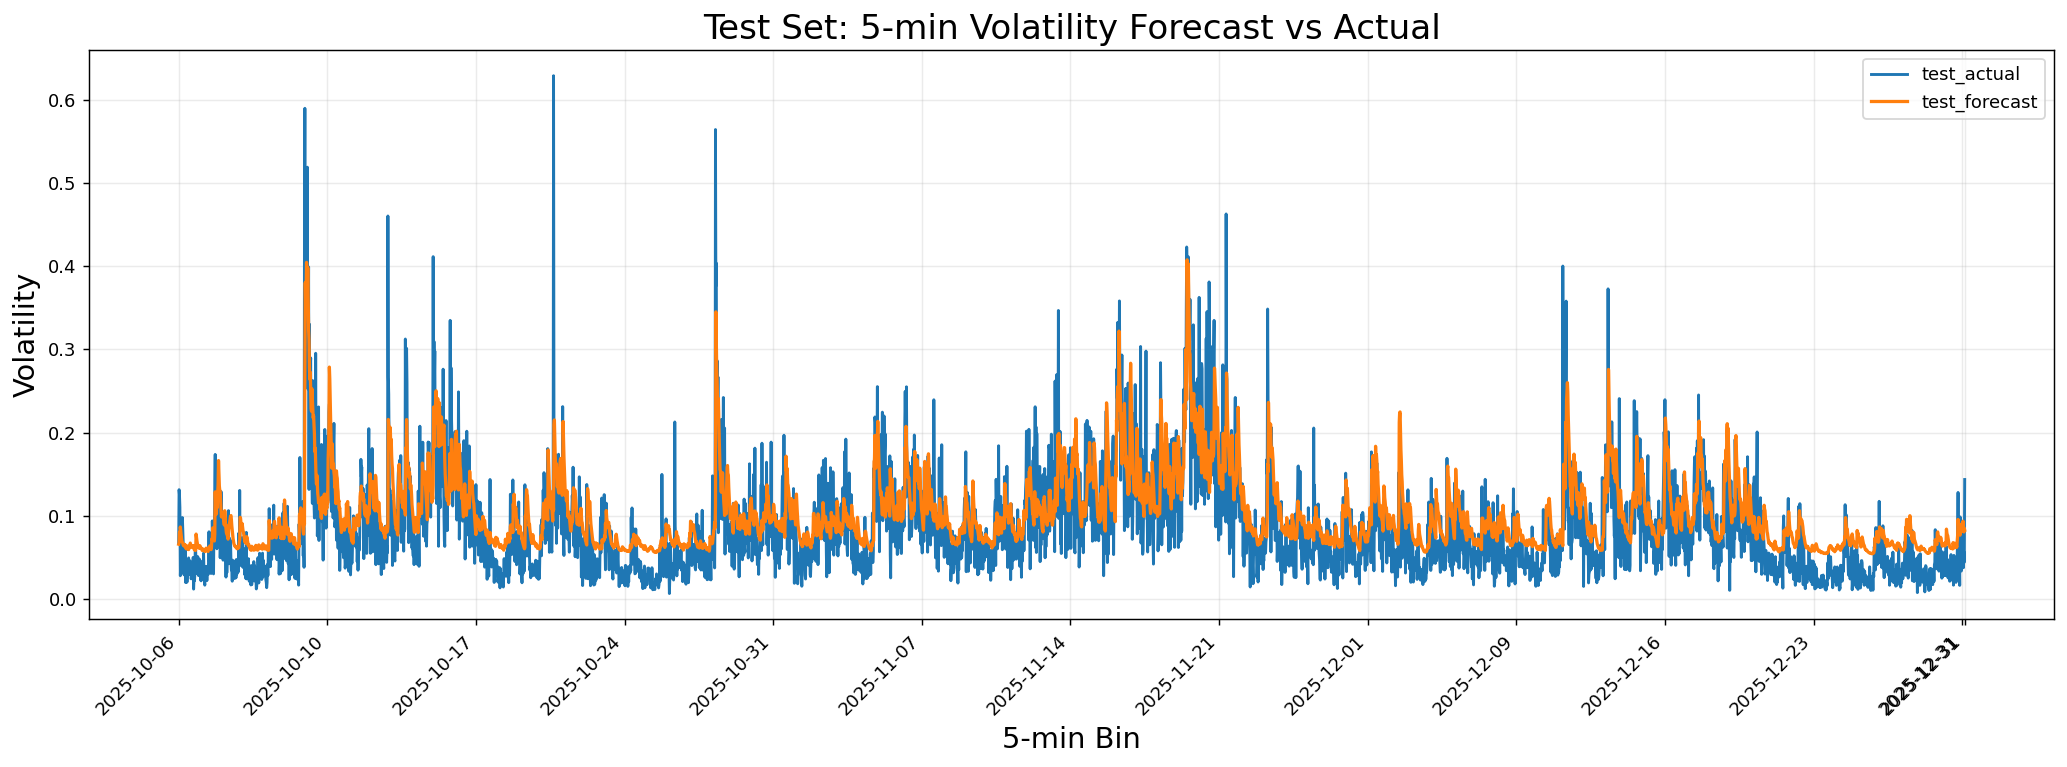

In [9]:
test_snap = pd.to_datetime(test_data["bar5"].values)

test_x_relative = np.arange(len(vol_test))

all_dates_test = list(test_snap.strftime("%Y-%m-%d"))
all_x_test = np.arange(len(all_dates_test))
tick_step = max(1, len(all_x_test) // 12)
tick_idx = list(range(0, len(all_x_test), tick_step))
if tick_idx[-1] != len(all_x_test) - 1:
    tick_idx.append(len(all_x_test) - 1)

plt.figure(figsize=(16, 6))
plt.plot(test_x_relative, actual_test_vols, label="test_actual", linewidth=1.6)
plt.plot(test_x_relative, vol_test, label="test_forecast", linewidth=1.8)

plt.xticks(tick_idx, [all_dates_test[i] for i in tick_idx], rotation=45, ha="right")
plt.title("Test Set: 5-min Volatility Forecast vs Actual", fontsize=19)
plt.xlabel("5-min Bin", fontsize=16)
plt.ylabel("Volatility", fontsize=16)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
from pathlib import Path

forecast_path = Path(r"C:\Users\Franswa\Documents\TickStream\Option data dash\note\garch_spx_test_forecasts.npz")
forecast_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(forecast_path, actual=actual_test_vols, forecast=vol_test)
print(f"Saved GARCH SPX test forecasts to {forecast_path}")

Saved GARCH SPX test forecasts to C:\Users\Franswa\Documents\TickStream\Option data dash\note\garch_spx_test_forecasts.npz


In [11]:
threshold = 0.02  # ~2% annualized — effectively "near zero"

near_zero_mask = actual_test_vols < threshold
near_zero_test = actual_test_vols[near_zero_mask]
near_zero_dt   = pd.to_datetime(test_data["bar5"].values)[near_zero_mask]

print(f"Test bins with actual_vol < {threshold}: {len(near_zero_test):,} / {len(actual_test_vols):,}")
print(f"actual_vol_test range: {actual_test_vols.min():.6f} – {actual_test_vols.max():.4f}")
print(f"vol_test (GARCH) range: {vol_test.min():.6f} – {vol_test.max():.4f}")
print(f"\nTime-of-day breakdown of near-zero test bins:")
time_counts = pd.Series(near_zero_dt.time).value_counts().sort_index()
print(time_counts.to_string())


Test bins with actual_vol < 0.02: 151 / 4,303
actual_vol_test range: 0.006388 – 0.6292
vol_test (GARCH) range: 0.054286 – 0.4077

Time-of-day breakdown of near-zero test bins:
10:20:00    1
10:40:00    1
10:45:00    1
10:50:00    1
11:00:00    1
11:15:00    2
11:20:00    1
11:25:00    2
11:30:00    2
11:35:00    1
11:55:00    2
12:00:00    2
12:05:00    2
12:10:00    3
12:15:00    4
12:20:00    2
12:25:00    1
12:30:00    3
12:35:00    2
12:40:00    2
12:45:00    2
12:50:00    2
12:55:00    4
13:00:00    2
13:05:00    2
13:10:00    2
13:15:00    1
13:25:00    2
13:30:00    2
13:35:00    2
13:40:00    1
13:45:00    4
13:50:00    3
13:55:00    7
14:00:00    2
14:05:00    4
14:10:00    6
14:15:00    3
14:20:00    2
14:25:00    7
14:30:00    3
14:35:00    5
14:40:00    6
14:45:00    4
14:50:00    2
14:55:00    4
15:00:00    2
15:05:00    2
15:10:00    5
15:15:00    4
15:20:00    4
15:25:00    4
15:30:00    3
15:35:00    2
15:40:00    4
15:50:00    1


In [13]:
# Retrain GARCH(1,1) on processed sets and report concise metrics
import os, sys, json, time


def find_project_root(marker_dir='34_features_newvol'):
    p = os.getcwd()
    while True:
        if os.path.isdir(os.path.join(p, marker_dir)):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            raise FileNotFoundError(f"Could not find '{marker_dir}' in any parent of cwd={os.getcwd()}")
        p = parent

ROOT = find_project_root()
OUTDIR = os.path.join(ROOT, '34_features_newvol', 'processed_sets')
SUMMARY = os.path.join(OUTDIR, 'summary.json')
with open(SUMMARY, 'r') as f:
    summary = json.load(f)

datasets = {
    'original': os.path.join(ROOT, '34_features_newvol', 'train_features_5m_clean.parquet'),
    'removed_peak_month': os.path.join(OUTDIR, os.path.basename(summary['removed_peak_month']['path'])),
    'winsorized_1_99': os.path.join(OUTDIR, os.path.basename(summary['winsorized_1_99']['path'])),
    'regime_high_vol': os.path.join(OUTDIR, os.path.basename(summary['regime_high_vol']['path'])),
    'regime_low_vol': os.path.join(OUTDIR, os.path.basename(summary['regime_low_vol']['path'])),
}

rows = []
for name, path in datasets.items():

    df = pd.read_parquet(path)
    for col in ['bar5','prev_5m_log_return_1','target_ann_vol']:
        if col not in df.columns:
            raise RuntimeError(f"Missing column {col} in {name}")
    df = df[['bar5','prev_5m_log_return_1','target_ann_vol']].copy()
    df['bar5'] = pd.to_datetime(df['bar5'], errors='coerce')

    train_df = df[df['bar5'].dt.date < pd.Timestamp('2025-10-03').date()]
    test_df  = df[df['bar5'].dt.date >= pd.Timestamp('2025-10-06').date()]

    n_train, n_test = len(train_df), len(test_df)

    if n_train < 30 or n_test < 1:
        rows.append({'dataset': name, 'note': 'insufficient data'})
        continue

    lr_train = train_df['prev_5m_log_return_1'].to_numpy(dtype=float)
    lr_test  = test_df['prev_5m_log_return_1'].to_numpy(dtype=float)
    act_train = train_df['target_ann_vol'].to_numpy(dtype=float)
    act_test  = test_df['target_ann_vol'].to_numpy(dtype=float)

    r_full = pd.Series(np.concatenate([lr_train, lr_test])) * SCALE

    t0 = time.time()
    res = arch_model(r_full, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=False)\
            .fit(last_obs=len(lr_train), disp='off', update_freq=0)
    fit_time = time.time() - t0

    vol_train = (res.conditional_volatility.iloc[:n_train].to_numpy() / SCALE) * ANN_5M
    fc_var = res.forecast(horizon=1, start=n_train, reindex=True).variance['h.1'].iloc[n_train:n_train+n_test].to_numpy()
    vol_test = (np.sqrt(fc_var) / SCALE) * ANN_5M

    train_metrics = fc.regression_metrics(act_train, vol_train, prefix=f"{name}_train")
    test_metrics  = fc.regression_metrics(act_test, vol_test, prefix=f"{name}_test")

    rows.append({
        'dataset': name,
        'n_train': n_train,
        'n_test': n_test,
        'fit_time_s': float(fit_time),
        'train_MAE': train_metrics[f"{name}_train_MAE"],
        'train_RMSE': train_metrics[f"{name}_train_RMSE"],
        'train_R2': train_metrics[f"{name}_train_R2"],
        'test_MAE': test_metrics[f"{name}_test_MAE"],
        'test_RMSE': test_metrics[f"{name}_test_RMSE"],
        'test_R2': test_metrics[f"{name}_test_R2"],
        'params': res.params.to_dict(),
        'std_err': res.std_err.to_dict(),
        'tvalues': res.tvalues.to_dict(),
        'pvalues': res.pvalues.to_dict(),
    })

metrics_df = pd.DataFrame(rows).set_index('dataset').drop(columns=['params', 'std_err', 'tvalues', 'pvalues'])
params_df = pd.DataFrame(
    [
        {
            'dataset': row['dataset'],
            **{f"{param}_estimate": estimate for param, estimate in row['params'].items()},
            **{f"{param}_std_err": std_err for param, std_err in row['std_err'].items()},
            **{f"{param}_tvalue": tvalue for param, tvalue in row['tvalues'].items()},
            **{f"{param}_pvalue": pvalue for param, pvalue in row['pvalues'].items()},
        }
        for row in rows if 'params' in row
    ]
).set_index('dataset')

print('\n==== Retrain Summary ===')
print(metrics_df)
print('\n==== Fitted GARCH(1,1) Parameters (estimate, std.error, t-value, p-value) ===')
print(params_df)



==== Retrain Summary ===
                    n_train  n_test  fit_time_s  train_MAE  train_RMSE  \
dataset                                                                  
original               9628    4303    0.034502   0.048293    0.103369   
removed_peak_month     9412    4303    0.074950   0.038085    0.057516   
winsorized_1_99        9628    4303    0.034026   0.047553    0.100334   
regime_high_vol        4823    2325    0.033599   0.074855    0.155587   
regime_low_vol         4805    1978    0.038192   0.022582    0.029662   

                    train_R2  test_MAE  test_RMSE   test_R2  
dataset                                                      
original            0.458978  0.035699   0.047063  0.483329  
removed_peak_month  0.500386  0.031578   0.044679  0.486663  
winsorized_1_99     0.432951  0.035572   0.046317  0.490647  
regime_high_vol     0.366134  0.050824   0.065362  0.304708  
regime_low_vol      0.116119  0.022284   0.027729  0.216305  

==== Fitted GARCH(1,